In [1]:
!pip install mediapipe opencv-python tensorflow
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models

In [21]:
!unzip -o sign-language-mnist.zip

Archive:  sign-language-mnist.zip
  inflating: amer_sign2.png          
  inflating: amer_sign3.png          
  inflating: american_sign_language.PNG  
  inflating: sign_mnist_test.csv     
  inflating: sign_mnist_test/sign_mnist_test.csv  
  inflating: sign_mnist_train.csv    
  inflating: sign_mnist_train/sign_mnist_train.csv  


In [22]:
!kaggle datasets download -d datamunge/sign-language-mnist -o
!unzip -o sign-language-mnist.zip

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
  0% 0.00/62.6M [00:00<?, ?B/s]
100% 62.6M/62.6M [00:00<00:00, 527MB/s]
Archive:  sign-language-mnist.zip
  inflating: amer_sign2.png          
  inflating: amer_sign3.png          
  inflating: american_sign_language.PNG  
  inflating: sign_mnist_test.csv     
  inflating: sign_mnist_test/sign_mnist_test.csv  
  inflating: sign_mnist_train.csv    
  inflating: sign_mnist_train/sign_mnist_train.csv  


In [24]:
import pandas as pd

train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

# Split features and labels
X_train = train.iloc[:, 1:].values.reshape(-1, 28, 28, 1)
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values.reshape(-1, 28, 28, 1)
y_test = test.iloc[:, 0].values

# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [25]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=25)  # 25 classes (A-Y, no J/Z)
y_test = to_categorical(y_test, num_classes=25)

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(25, activation='softmax')   # ✅ 25 classes (A–Y, no J/Z)
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.3485 - loss: 2.2427 - val_accuracy: 0.7699 - val_loss: 0.6851
Epoch 2/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.9200 - loss: 0.2938 - val_accuracy: 0.8811 - val_loss: 0.4066
Epoch 3/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9930 - loss: 0.0553 - val_accuracy: 0.8968 - val_loss: 0.3858
Epoch 4/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.9997 - loss: 0.0139 - val_accuracy: 0.8956 - val_loss: 0.4088
Epoch 5/5
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8995 - val_loss: 0.4068


In [13]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8991 - loss: 0.4040
Test Accuracy: 89.95%


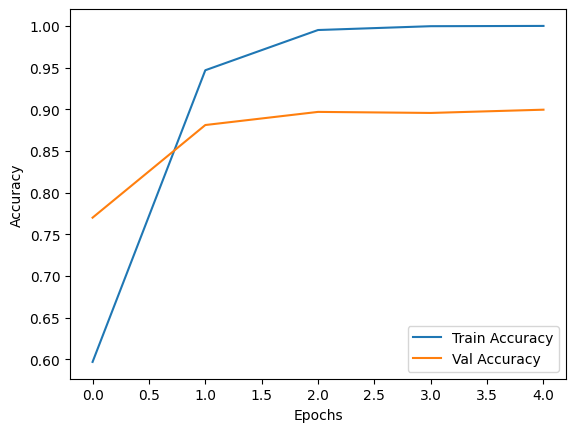

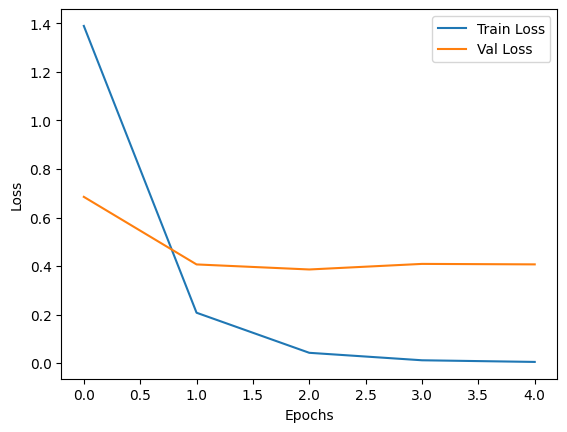

In [17]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
import string

# A–Z letters, but remove J (9) and Z (25)
letters = [ch for ch in string.ascii_uppercase if ch not in ['J','Z']]

print("Classes:", letters)

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


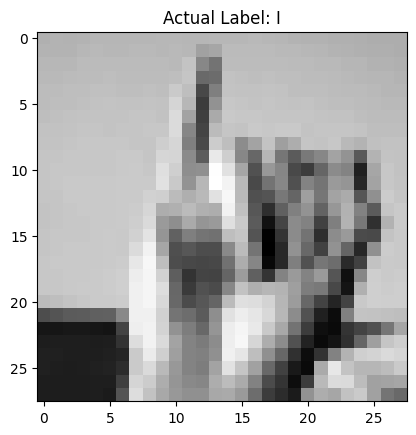

Predicted Label: I


In [28]:
i = 100  # choose test image index

plt.imshow(X_test[i].reshape(28,28), cmap="gray")
plt.title(f"Actual Label: {letters[np.argmax(y_test[i])]}")
plt.show()

pred = model.predict(X_test[i].reshape(1,28,28,1), verbose=0)
predicted_class = np.argmax(pred)

print("Predicted Label:", letters[predicted_class])